<a href="https://colab.research.google.com/github/brknatmaca/group-5---Analyzing-Global-CO2-Emissions-and-the-Renewable-Energy-Transition-/blob/main/samsung2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import wbgapi as wb


In [2]:
df = pd.read_csv('sustainable_energy.csv')

df_cleaned = df.drop(columns=['Financial flows to developing countries (US $)', 'Renewables (% equivalent primary energy)'], errors='ignore')
df_cleaned = df_cleaned.sort_values(by=['Entity', 'Year'])
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

In [3]:
for col in numeric_cols:
    df_cleaned[col] = df_cleaned.groupby('Entity')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both').fillna(x.median()))
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

In [4]:
#WORLD BANK API INTEGRATION (urban population)
df_urban_api = wb.data.DataFrame('SP.URB.TOTL.IN.ZS', time=range(2000, 2021), labels=True).reset_index()
df_urban_api = df_urban_api.rename(columns={'Country': 'Entity'}).drop(columns=['economy'], errors='ignore')
df_urban = df_urban_api.melt(id_vars=['Entity'], var_name='Year', value_name='Urban_Population_Percent')
df_urban['Year'] = df_urban['Year'].str.replace('YR', '').astype(int)

if 'Urban_Population_Percent' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['Urban_Population_Percent'])

df_cleaned = pd.merge(df_cleaned, df_urban, on=['Entity', 'Year'], how='left')
df_cleaned['Urban_Population_Percent'] = df_cleaned.groupby('Entity')['Urban_Population_Percent'].transform(lambda x: x.fillna(x.median()))
df_cleaned['Urban_Population_Percent'] = df_cleaned['Urban_Population_Percent'].fillna(df_cleaned['Urban_Population_Percent'].median())

In [5]:
#WORLD BANK LPI INTEGRATION (Logistic Performance)

df_lpi_wb = pd.read_csv('API_LP.LPI.OVRL.XQ_DS2_en_csv_v2_121626.csv', skiprows=4)
df_lpi_wb = df_lpi_wb.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code', 'Unnamed: 68', 'Unnamed: 69'], errors='ignore')
df_lpi = df_lpi_wb.melt(id_vars=['Country Name'], var_name='Year', value_name='LPI_Score')
df_lpi['Year'] = pd.to_numeric(df_lpi['Year'], errors='coerce')
df_lpi = df_lpi.dropna(subset=['Year']).astype({'Year': int})
df_lpi = df_lpi.rename(columns={'Country Name': 'Entity'})

if 'LPI_Score' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['LPI_Score'])

df_cleaned = pd.merge(df_cleaned, df_lpi, on=['Entity', 'Year'], how='left')
df_cleaned = df_cleaned.sort_values(by=['Entity', 'Year'])
df_cleaned['LPI_Score'] = df_cleaned.groupby('Entity')['LPI_Score'].transform(lambda x: x.ffill().bfill())
df_cleaned['LPI_Score'] = df_cleaned['LPI_Score'].fillna(df_cleaned['LPI_Score'].median())

numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns


--- Top 10 Highest Correlations ---
Value_co2_emissions_kt_by_country                                 Electricity from fossil fuels (TWh)                   0.989270
Access to clean fuels for cooking                                 Access to electricity (% of population)               0.867734
Value_co2_emissions_kt_by_country                                 Electricity from renewables (TWh)                     0.858484
Electricity from renewables (TWh)                                 Electricity from fossil fuels (TWh)                   0.845103
Renewable energy share in the total final energy consumption (%)  Access to clean fuels for cooking                    -0.788789
                                                                  Access to electricity (% of population)              -0.782845
Urban_Population_Percent                                          Access to clean fuels for cooking                     0.718935
Land Area(Km2)                                              

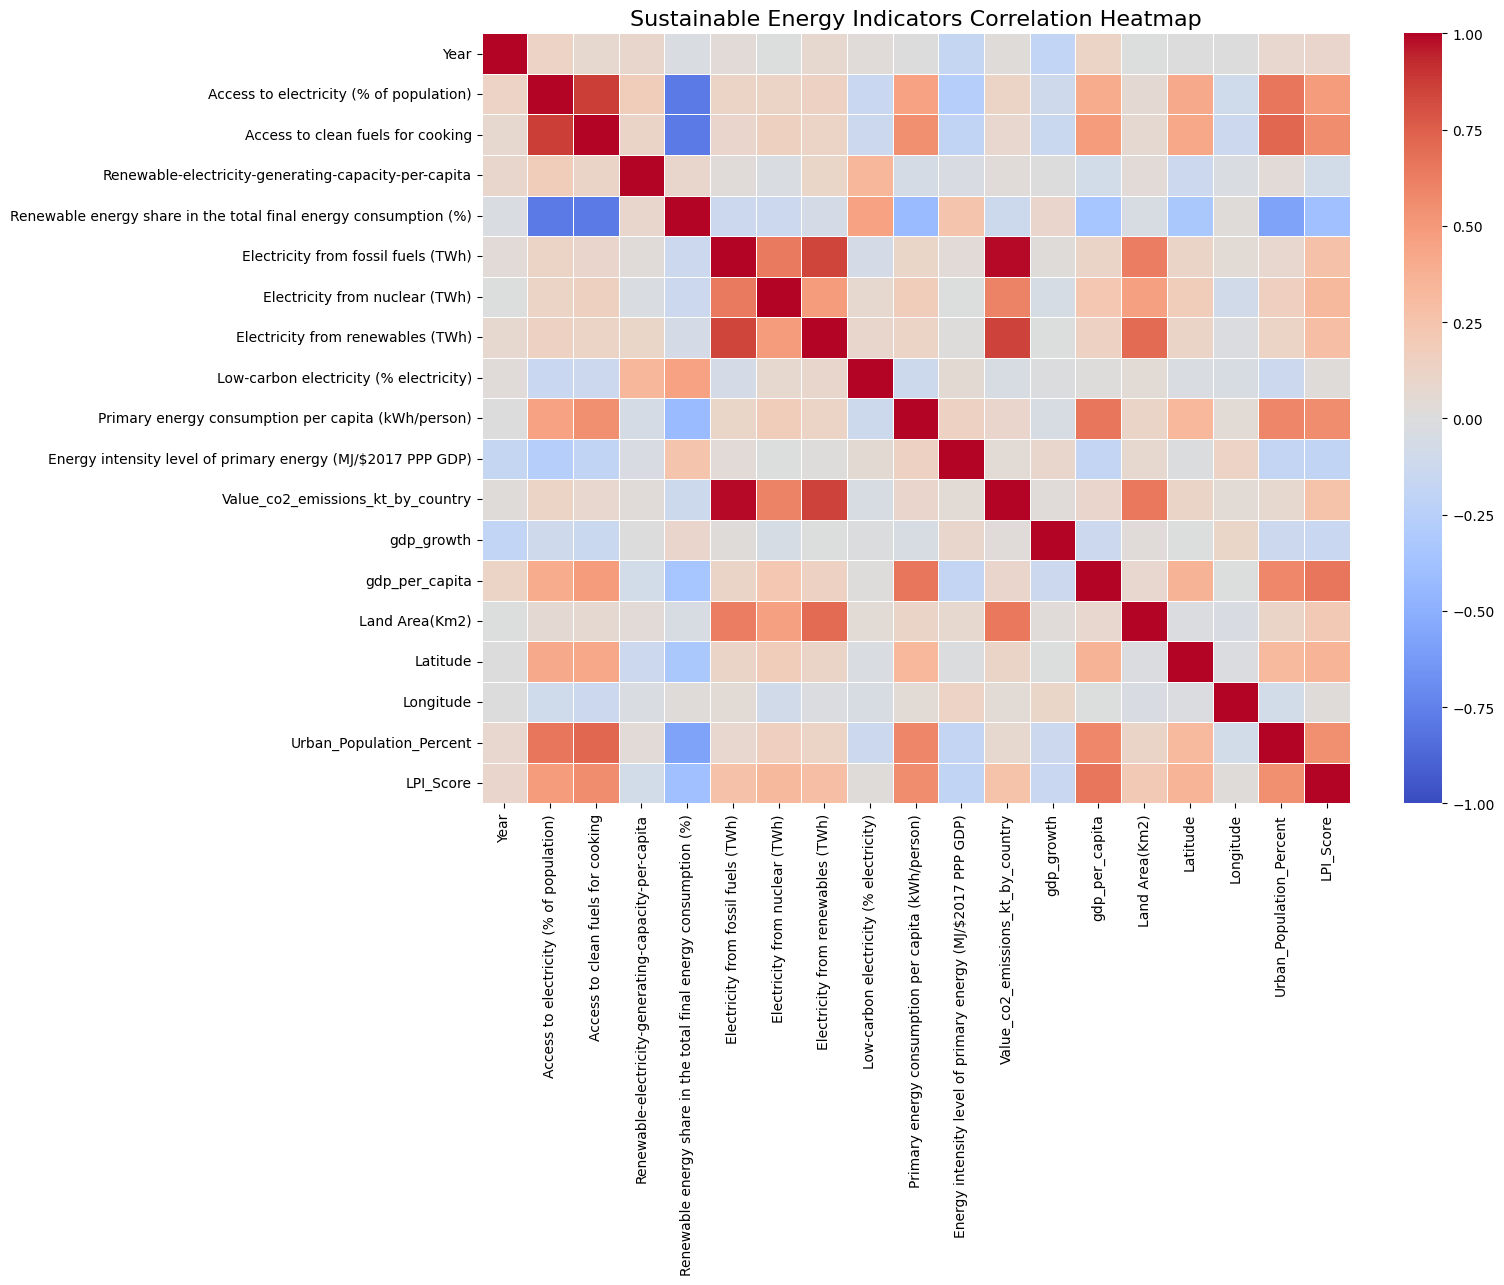

In [6]:

pd.reset_option('display.float_format')
corr_matrix = df_cleaned[numeric_cols].corr()
print("\n--- Top 10 Highest Correlations ---")
upper_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
print(upper_corr.unstack().dropna().sort_values(ascending=False, key=abs).head(10).to_string())

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Sustainable Energy Indicators Correlation Heatmap', fontsize=16)
plt.show()

In [7]:
target_col = 'Value_co2_emissions_kt_by_country'
threshold = 0.85
columns_to_drop = [col for col in upper_corr.columns if any(upper_corr.abs()[col] > threshold)]

# Protect essential columns from being dropped
for col_to_protect in [target_col, 'LPI_Score', 'Urban_Population_Percent']:
    if col_to_protect in columns_to_drop:
        columns_to_drop.remove(col_to_protect)

df_cleaned = df_cleaned.drop(columns=columns_to_drop, errors='ignore')
print(f"\nColumns dropped due to high correlation (>0.85): {columns_to_drop}")


Columns dropped due to high correlation (>0.85): ['Access to clean fuels for cooking']


In [8]:
existing_numeric_cols = [c for c in numeric_cols if c in df_cleaned.columns]
print("\n--- Descriptive Statistics ---")
display(df_cleaned[existing_numeric_cols].describe().T)

print("\n--- Skewness Analysis ---")
print(df_cleaned[existing_numeric_cols].skew().sort_values(ascending=False))




--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
Year,3649.0,2010.038367,6.054228e+00,2000.000000,2005.000000,2010.000000,2015.000000,2.020000e+03
Access to electricity (% of population),3649.0,78.750760,3.047191e+01,1.252269,59.137558,98.272340,100.000000,1.000000e+02
Renewable-electricity-generating-capacity-per-capita,3649.0,92.668383,2.136031e+02,0.000000,8.390000,32.910000,67.600000,3.060190e+03
Renewable energy share in the total final energy consumption (%),3649.0,32.507096,2.970487e+01,0.000000,6.700000,23.325000,54.670000,9.604000e+01
Electricity from fossil fuels (TWh),3649.0,69.977144,3.470861e+02,0.000000,0.300000,2.970000,26.520000,5.184130e+03
Electricity from nuclear (TWh),3649.0,12.985755,7.177678e+01,0.000000,0.000000,0.000000,0.000000,8.094100e+02
Electricity from renewables (TWh),3649.0,23.838534,1.041440e+02,0.000000,0.050000,1.470000,9.560000,2.184940e+03
Low-carbon electricity (% electricity),3649.0,36.698327,3.413009e+01,0.000000,3.030303,27.865068,64.022670,1.000000e+02
Primary energy consumption per capita (kWh/person),3649.0,25743.981745,3.477322e+04,0.000000,3116.737300,13120.570000,33892.780000,2.625857e+05
Energy intensity level of primary energy (MJ/$2017 PPP GDP),3649.0,5.252228,3.486272e+00,0.110000,3.160000,4.280000,5.970000,3.257000e+01



--- Skewness Analysis ---
Electricity from renewables (TWh)                                   11.088766
Value_co2_emissions_kt_by_country                                    9.752190
Electricity from fossil fuels (TWh)                                  9.424156
Electricity from nuclear (TWh)                                       8.720780
Renewable-electricity-generating-capacity-per-capita                 6.244236
Land Area(Km2)                                                       4.635739
Primary energy consumption per capita (kWh/person)                   2.651621
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          2.608681
gdp_growth                                                           2.556781
gdp_per_capita                                                       2.471683
LPI_Score                                                            0.815567
Renewable energy share in the total final energy consumption (%)     0.682528
Low-carbon electricity (% electricity

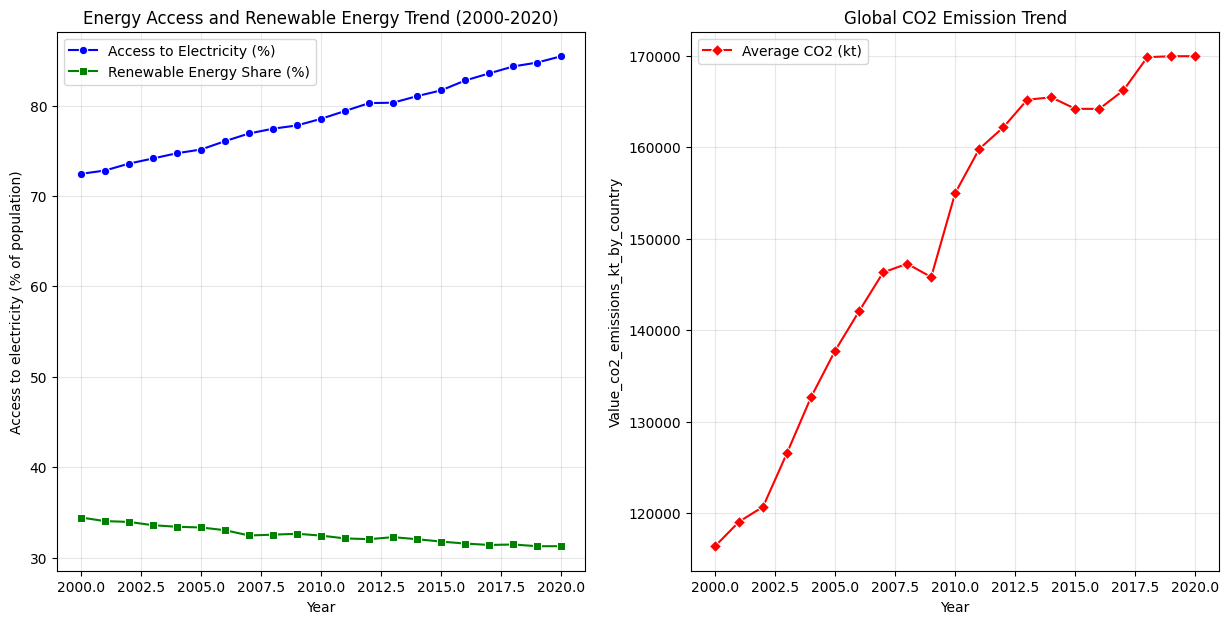

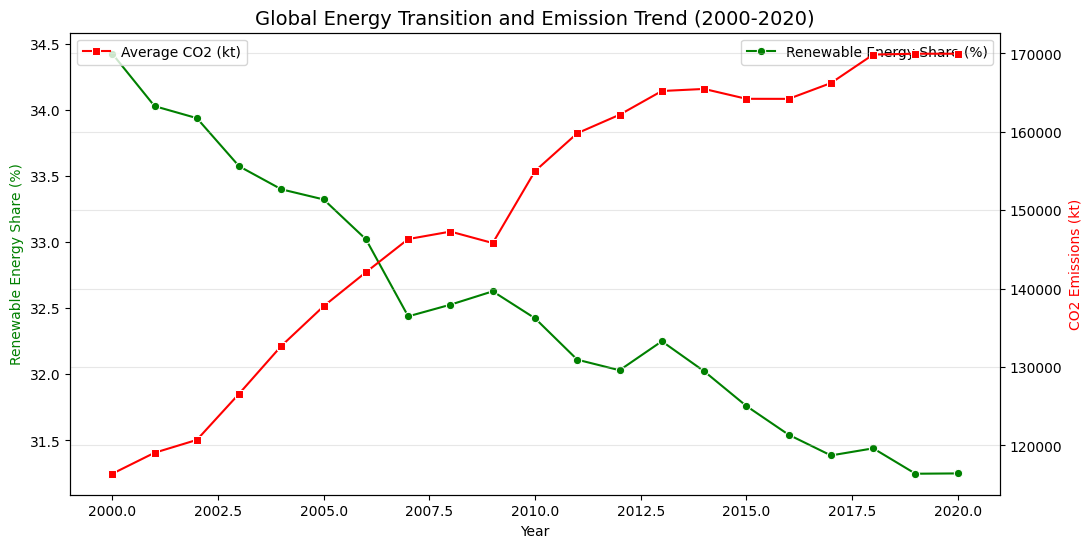

In [9]:
plt.figure(figsize=(15, 7))
agg_dict = {c: 'mean' for c in ['Access to electricity (% of population)', 'Renewable energy share in the total final energy consumption (%)', target_col] if c in df_cleaned.columns}
trend_df = df_cleaned.groupby('Year').agg(agg_dict).reset_index()

plt.subplot(1, 2, 1)
if 'Access to electricity (% of population)' in trend_df.columns:
    sns.lineplot(data=trend_df, x='Year', y='Access to electricity (% of population)', marker='o', label='Access to Electricity (%)', color='blue')
if 'Renewable energy share in the total final energy consumption (%)' in trend_df.columns:
    sns.lineplot(data=trend_df, x='Year', y='Renewable energy share in the total final energy consumption (%)', marker='s', label='Renewable Energy Share (%)', color='green')
plt.title('Energy Access and Renewable Energy Trend (2000-2020)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if target_col in trend_df.columns:
    sns.lineplot(data=trend_df, x='Year', y=target_col, marker='D', color='red', label='Average CO2 (kt)')
plt.title('Global CO2 Emission Trend')
plt.grid(True, alpha=0.3)
plt.show()


if target_col in df_cleaned.columns and 'Renewable energy share in the total final energy consumption (%)' in df_cleaned.columns:
    plt.figure(figsize=(12, 6))
    trend_data = df_cleaned.groupby('Year')[['Renewable energy share in the total final energy consumption (%)', target_col]].mean().reset_index()
    ax1 = sns.lineplot(data=trend_data, x='Year', y='Renewable energy share in the total final energy consumption (%)', color='green', label='Renewable Energy Share (%)', marker='o')
    ax2 = ax1.twinx()
    sns.lineplot(data=trend_data, x='Year', y=target_col, color='red', label='Average CO2 (kt)', marker='s', ax=ax2)
    ax1.set_title('Global Energy Transition and Emission Trend (2000-2020)', fontsize=14)
    ax1.set_ylabel('Renewable Energy Share (%)', color='green')
    ax2.set_ylabel('CO2 Emissions (kt)', color='red')
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
X = df_cleaned.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')
y = df_cleaned[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
min_max_cols = [a for a in ['Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable energy share in the total final energy consumption (%)', 'Low-carbon electricity (% electricity)','Urban_Population_Percent', 'LPI_Score'] if a in X_train.columns]
if min_max_cols:
    minmax_scaler = MinMaxScaler()
    X_train.loc[:, min_max_cols] = minmax_scaler.fit_transform(X_train[min_max_cols])
    X_test.loc[:, min_max_cols] = minmax_scaler.transform(X_test[min_max_cols])

standard_cols = [a for a in ['gdp_per_capita', 'Primary energy consumption per capita (kWh/person)', 'Renewable-electricity-generating-capacity-per-capita'] if a in X_train.columns]
if standard_cols:
    std_scaler = StandardScaler()
    X_train.loc[:, standard_cols] = std_scaler.fit_transform(X_train[standard_cols])
    X_test.loc[:, standard_cols] = std_scaler.transform(X_test[standard_cols])

In [14]:
def calculate_advanced_metrics(y_true, y_pred, y_train_data):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    mase = mae / np.mean(np.abs(y_true - np.mean(y_train_data)))
    return r2, mae, rmse, mape, mase

/tmp/ipykernel_57273/3343087430.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[3], palette='viridis')


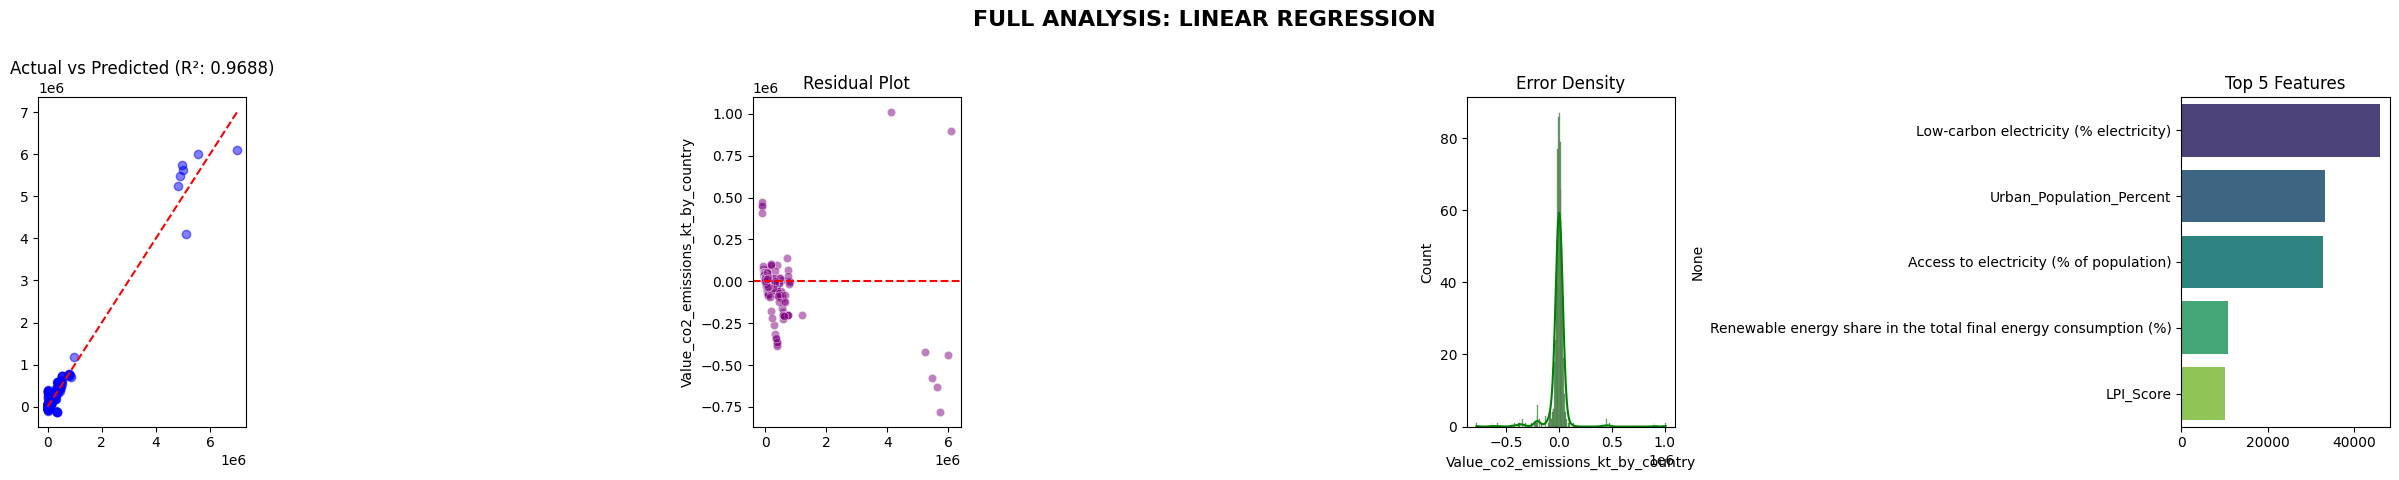


--- Linear Regression PERFORMANCE SUMMARY ---
METRICS -> R2: 0.9688 | RMSE: 94330.13 | MAE: 37206.97 | MAPE: %2268.60 | MASE: 0.1920

[BEST 3 PREDICTIONS]
   Entity  Year      Actual    Predicted  Abs_Error
  Grenada  2000   210.00000   211.292226   1.292226
    Chile  2012 78410.00366 78352.195405  57.808255
Nicaragua  2001  3930.00000  3810.965262 119.034738

[WORST 3 PREDICTIONS]
       Entity  Year      Actual    Predicted    Abs_Error
        China  2004 5124819.824 4.115289e+06 1.009530e+06
        China  2007 6993180.176 6.094237e+06 8.989431e+05
United States  2012 4956060.059 5.734503e+06 7.784425e+05


/tmp/ipykernel_57273/3343087430.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[3], palette='viridis')


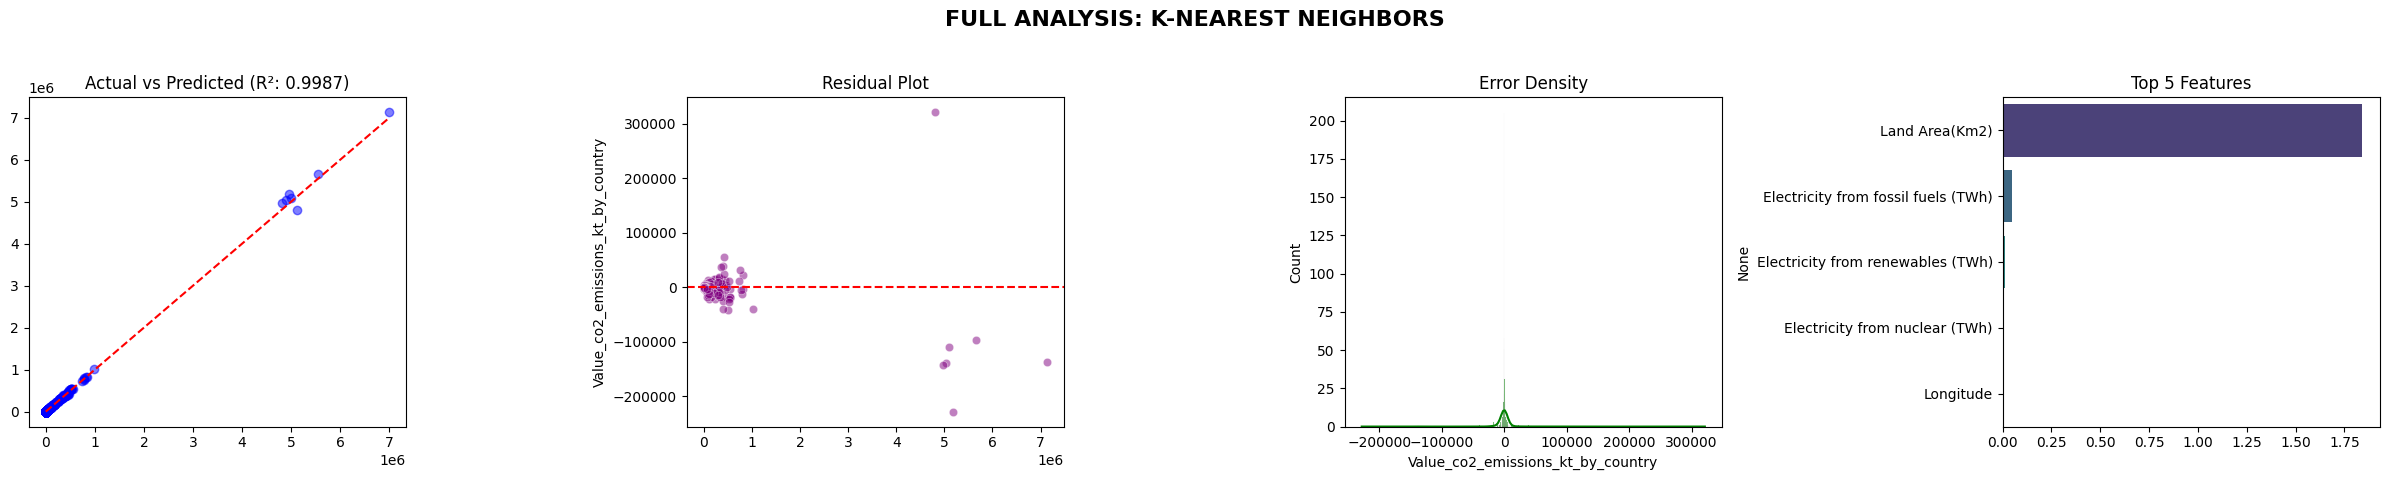


--- K-Nearest Neighbors PERFORMANCE SUMMARY ---
METRICS -> R2: 0.9987 | RMSE: 18946.46 | MAE: 4043.44 | MAPE: %8.50 | MASE: 0.0209

[BEST 3 PREDICTIONS]
  Entity  Year      Actual   Predicted  Abs_Error
   Yemen  2012 10480.00002 10480.00002        0.0
   Egypt  2010 10480.00002 10480.00002        0.0
Slovakia  2002 10480.00002 10480.00002        0.0

[WORST 3 PREDICTIONS]
       Entity  Year      Actual    Predicted   Abs_Error
        China  2004 5124819.824 4803430.0626 321389.7614
United States  2012 4956060.059 5184290.0392 228229.9802
United States  2017 4819370.117 4962012.1096 142641.9926


/tmp/ipykernel_57273/3343087430.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[3], palette='viridis')


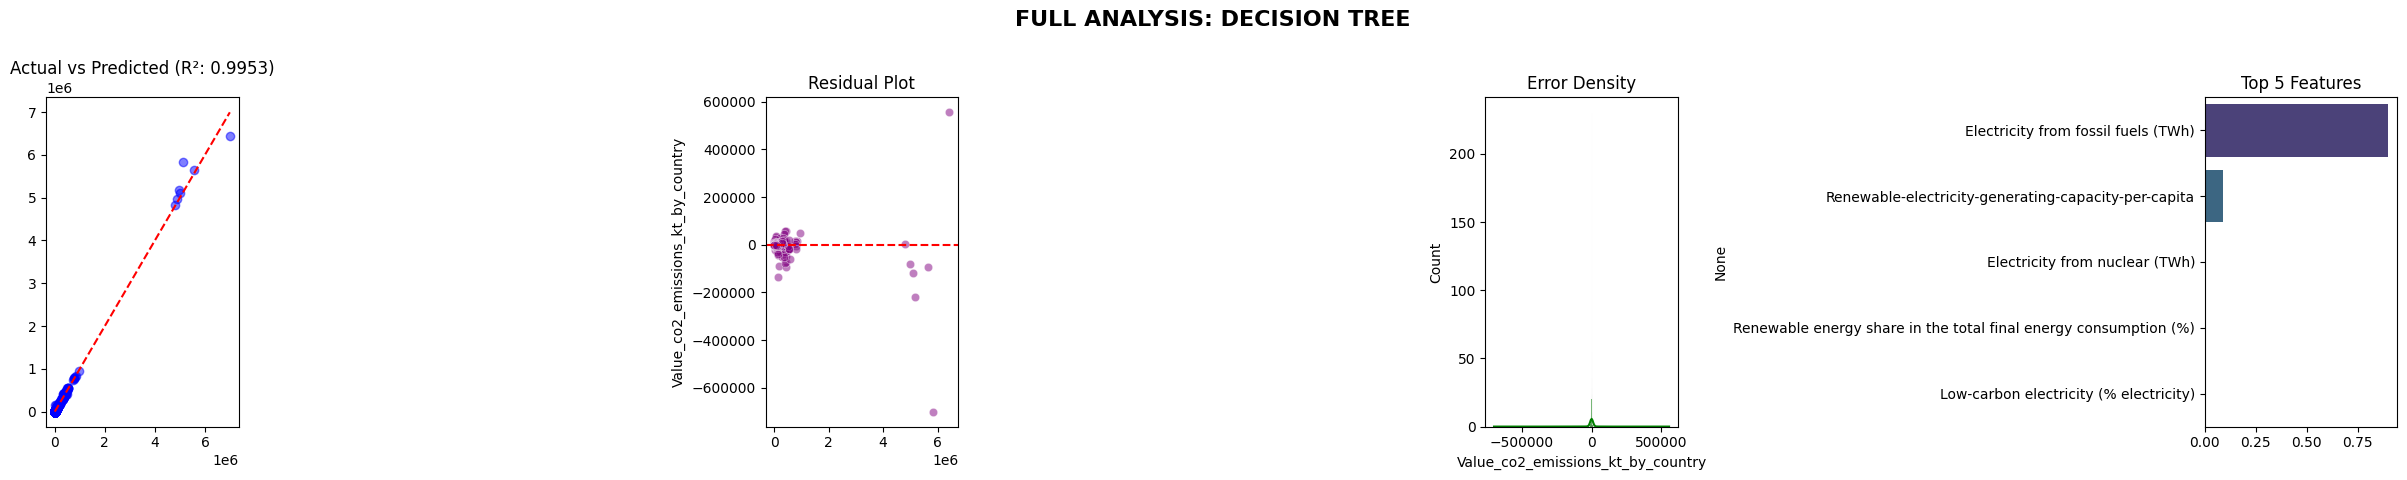


--- Decision Tree PERFORMANCE SUMMARY ---
METRICS -> R2: 0.9953 | RMSE: 36441.32 | MAE: 6263.87 | MAPE: %12.01 | MASE: 0.0323

[BEST 3 PREDICTIONS]
 Entity  Year       Actual    Predicted  Abs_Error
Somalia  2018   660.000026   660.000026        0.0
  Nauru  2009    39.999999    39.999999        0.0
 Greece  2020 60000.000000 60000.000000        0.0

[WORST 3 PREDICTIONS]
       Entity  Year      Actual   Predicted  Abs_Error
        China  2004 5124819.824 5824629.883 699810.059
        China  2007 6993180.176 6437470.215 555709.961
United States  2012 4956060.059 5173600.098 217540.039


/tmp/ipykernel_57273/3343087430.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[3], palette='viridis')


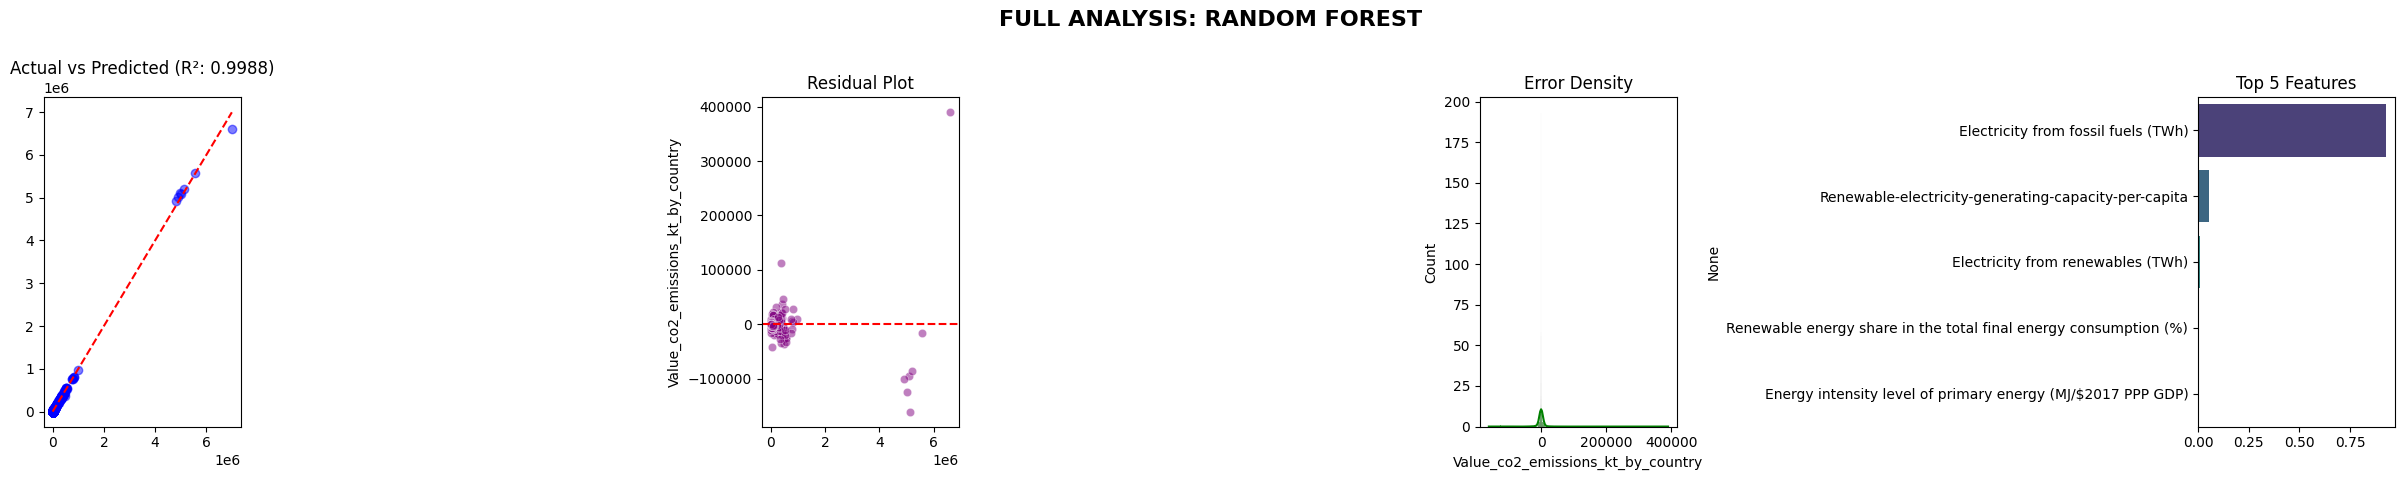


--- Random Forest PERFORMANCE SUMMARY ---
METRICS -> R2: 0.9988 | RMSE: 18845.88 | MAE: 4032.83 | MAPE: %13.00 | MASE: 0.0208

[BEST 3 PREDICTIONS]
 Entity  Year      Actual   Predicted    Abs_Error
 Gambia  2002 10480.00002 10480.00002 1.273293e-11
Bahamas  2008 10480.00002 10480.00002 1.273293e-11
  Congo  2010 10480.00002 10480.00002 1.273293e-11

[WORST 3 PREDICTIONS]
       Entity  Year      Actual    Predicted    Abs_Error
        China  2007 6993180.176 6.603606e+06 389573.73536
United States  2012 4956060.059 5.116740e+06 160680.42955
United States  2016 4894500.000 5.019338e+06 124838.16430


/tmp/ipykernel_57273/3343087430.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[3], palette='viridis')


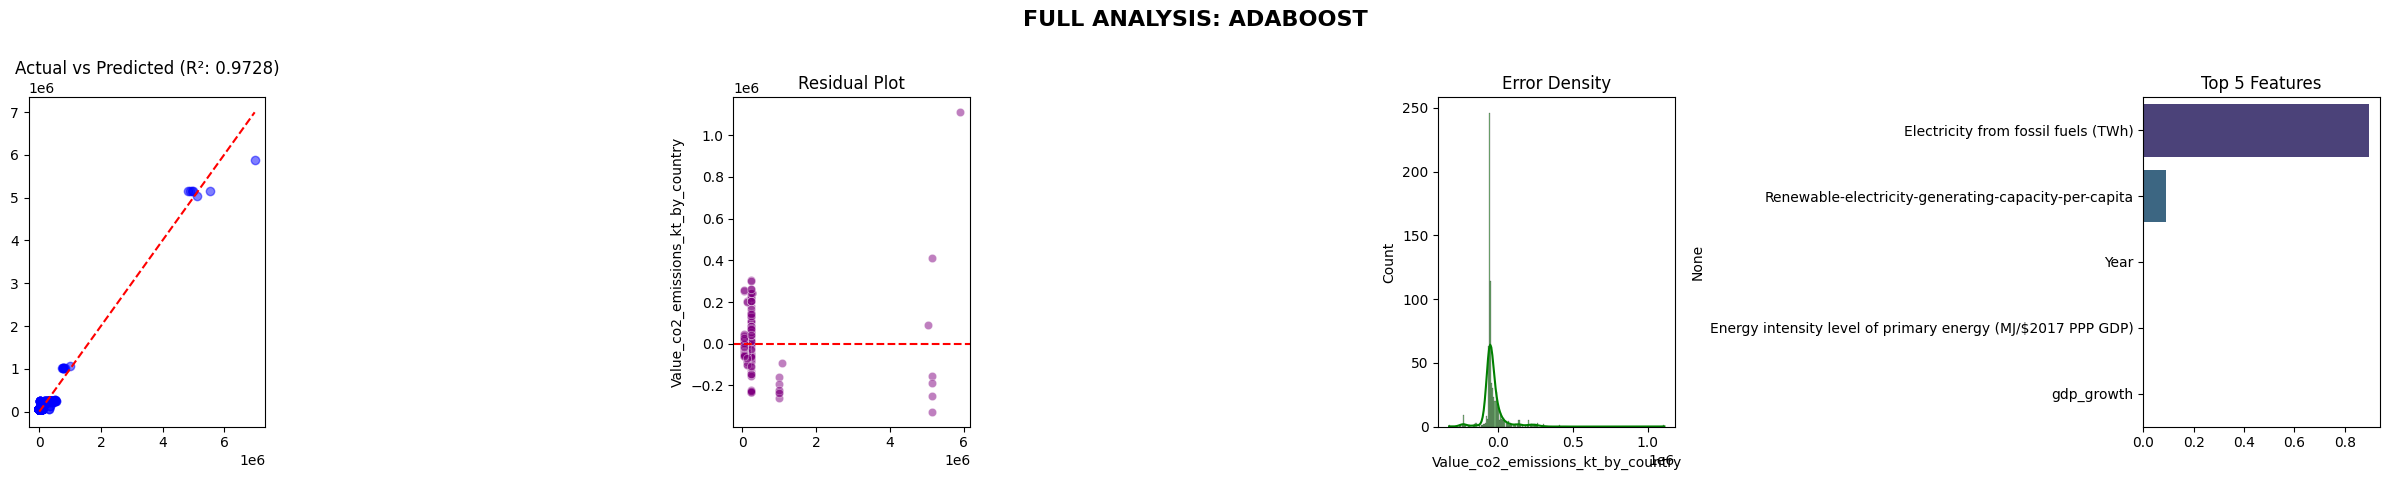


--- AdaBoost PERFORMANCE SUMMARY ---
METRICS -> R2: 0.9728 | RMSE: 88047.02 | MAE: 60989.42 | MAPE: %7919.56 | MASE: 0.3148

[BEST 3 PREDICTIONS]
  Entity  Year       Actual     Predicted  Abs_Error
Colombia  2001  58940.00000  58711.789344 228.210656
 Belarus  2006  59119.99893  58711.789344 408.209586
   Spain  2013 242809.99760 242316.603594 493.394006

[WORST 3 PREDICTIONS]
       Entity  Year      Actual    Predicted    Abs_Error
        China  2007 6993180.176 5.882989e+06 1.110192e+06
United States  2008 5558379.883 5.145173e+06 4.132068e+05
United States  2017 4819370.117 5.145173e+06 3.258029e+05


/tmp/ipykernel_57273/3343087430.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[3], palette='viridis')


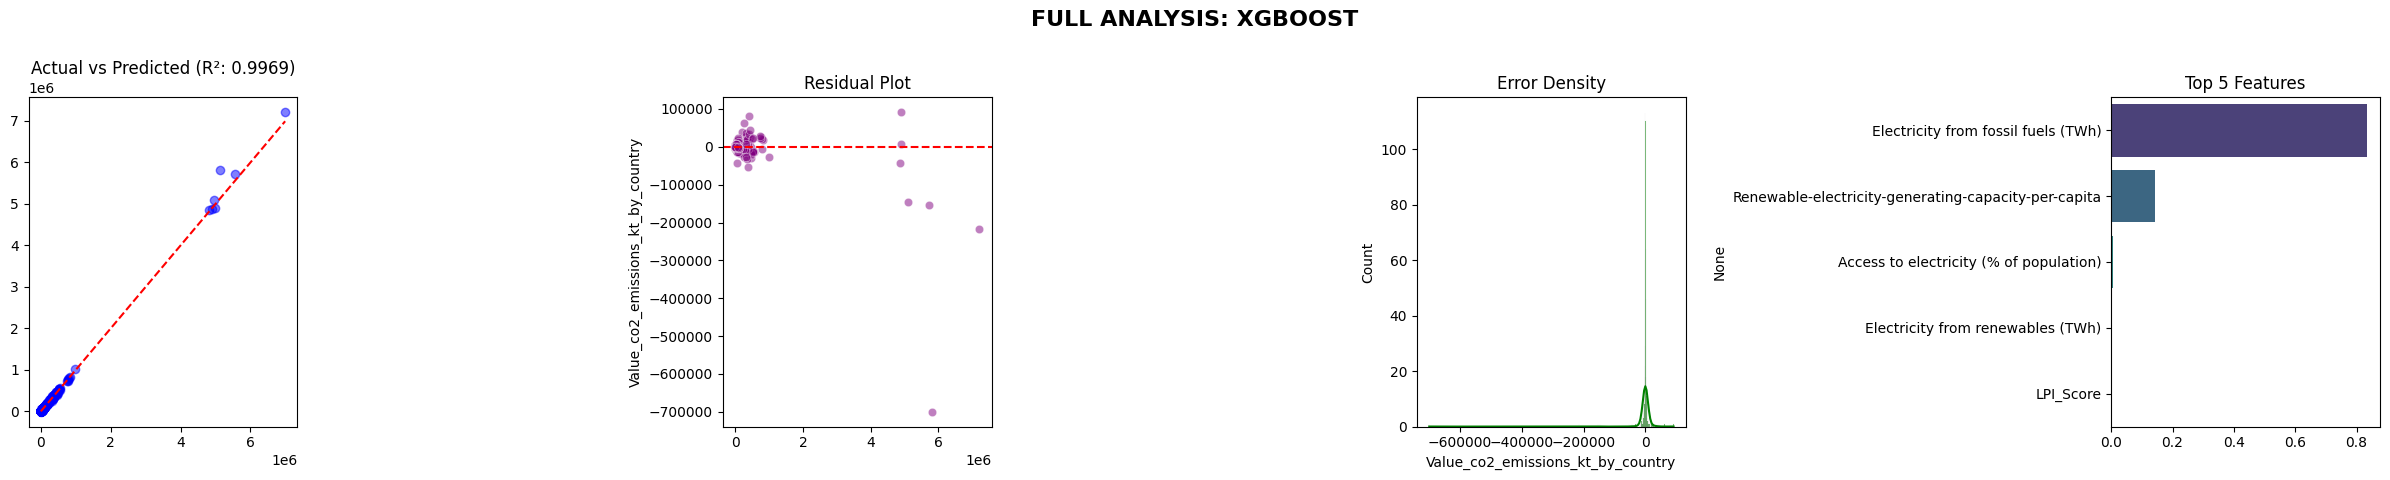


--- XGBoost PERFORMANCE SUMMARY ---
METRICS -> R2: 0.9969 | RMSE: 29502.82 | MAE: 5245.96 | MAPE: %78.64 | MASE: 0.0271

[BEST 3 PREDICTIONS]
 Entity  Year       Actual    Predicted  Abs_Error
   Cuba  2002 26420.000080 26420.894531   0.894451
  Haiti  2000  1470.000000  1465.218750   4.781250
Armenia  2018  5710.000038  5704.773926   5.226112

[WORST 3 PREDICTIONS]
       Entity  Year      Actual  Predicted  Abs_Error
        China  2004 5124819.824  5824374.0 699554.176
        China  2007 6993180.176  7209072.0 215891.824
United States  2008 5558379.883  5711914.5 153534.617


In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

results_summary = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2, mae, rmse, mape, mase = calculate_advanced_metrics(y_test, preds, y_train)
    residuals = y_test - preds
    results_summary[name] = {"preds": preds, "r2": r2, "mae": mae, "rmse": rmse, "mape": mape, "mase": mase}

    # GRAPHICS PANEL (4-Panel)
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle(f'FULL ANALYSIS: {name.upper()}', fontsize=16, fontweight='bold')

    axes[0].scatter(y_test, preds, alpha=0.5, color='blue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[0].set_title(f'Actual vs Predicted (R²: {r2:.4f})')

    sns.scatterplot(x=preds, y=residuals, ax=axes[1], color='purple', alpha=0.5)
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_title('Residual Plot')

    sns.histplot(residuals, kde=True, ax=axes[2], color='green')
    axes[2].set_title('Error Density')

    # Feature Importance
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
    elif hasattr(model, 'coef_'):
        importances = pd.Series(np.abs(model.coef_), index=X.columns).sort_values(ascending=False).head(5)
    else:
        perm_imp = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
        importances = pd.Series(perm_imp.importances_mean, index=X.columns).sort_values(ascending=False).head(5)

    sns.barplot(x=importances.values, y=importances.index, ax=axes[3], palette='viridis')
    axes[3].set_title('Top 5 Features')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # BEST 3 & WORST 3 PREDICTIONS
    temp_df = pd.DataFrame({
        'Entity': df_cleaned.loc[y_test.index, 'Entity'],
        'Year': df_cleaned.loc[y_test.index, 'Year'],
        'Actual': y_test,
        'Predicted': preds
    })
    temp_df['Abs_Error'] = np.abs(temp_df['Actual'] - temp_df['Predicted'])

    print(f"\n--- {name} PERFORMANCE SUMMARY ---")
    print(f"METRICS -> R2: {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: %{mape:.2f} | MASE: {mase:.4f}")
    print("\n[BEST 3 PREDICTIONS]")
    print(temp_df.sort_values('Abs_Error').head(3).to_string(index=False))
    print("\n[WORST 3 PREDICTIONS]")
    print(temp_df.sort_values('Abs_Error', ascending=False).head(3).to_string(index=False))
    print("="*90)


OVERALL MODEL PERFORMANCE COMPARISON


/tmp/ipykernel_57273/1560033776.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_r2.index, y=sorted_r2.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_57273/1560033776.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_mape.index, y=sorted_mape.values, ax=axes[2], palette='mako')


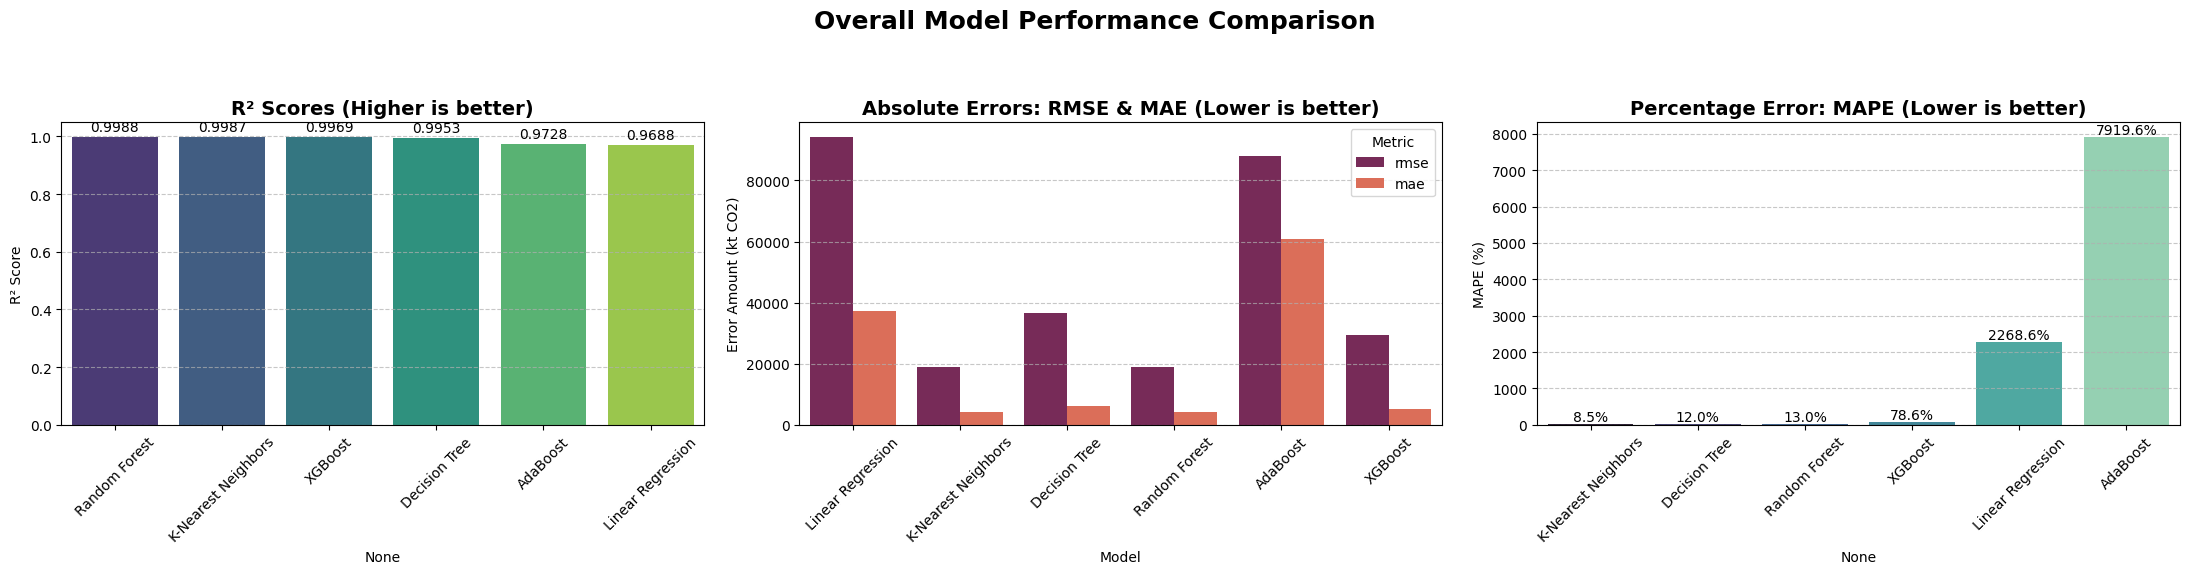

In [20]:
print("\n" + "="*60)
print("OVERALL MODEL PERFORMANCE COMPARISON")
print("="*60)

metrics_df = pd.DataFrame(results_summary).T
metrics_df = metrics_df.drop(columns=['preds']).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Overall Model Performance Comparison', fontsize=18, fontweight='bold')

# 1. R2 Scores
sorted_r2 = metrics_df['r2'].sort_values(ascending=False)
sns.barplot(x=sorted_r2.index, y=sorted_r2.values, ax=axes[0], palette='viridis')
axes[0].set_title('R² Scores (Higher is better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(sorted_r2.values):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. RMSE & MAE
error_df = metrics_df[['rmse', 'mae']].reset_index().rename(columns={'index': 'Model'})
error_melted = error_df.melt(id_vars='Model', var_name='Metric', value_name='Error_Value')
sns.barplot(data=error_melted, x='Model', y='Error_Value', hue='Metric', ax=axes[1], palette='rocket')
axes[1].set_title('Absolute Errors: RMSE & MAE (Lower is better)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Error Amount (kt CO2)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Metric')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. MAPE (Mean Absolute Percentage Error)
sorted_mape = metrics_df['mape'].sort_values(ascending=True)
sns.barplot(x=sorted_mape.index, y=sorted_mape.values, ax=axes[2], palette='mako')
axes[2].set_title('Percentage Error: MAPE (Lower is better)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MAPE (%)')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(sorted_mape.values):
    axes[2].text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

In [18]:
print("\n" + "="*60)
print("FINAL ACCURACY SUMMARY")
print("="*60)

total_preds = len(y_test)

for name, data in results_summary.items():
    errs = np.abs((y_test - data["preds"]) / (y_test + 1e-10)) * 100

    count_1 = np.sum(errs <= 1)
    count_5 = np.sum(errs <= 5)
    count_10 = np.sum(errs <= 10)

    pct_1 = (count_1 / total_preds) * 100
    pct_5 = (count_5 / total_preds) * 100
    pct_10 = (count_10 / total_preds) * 100

    print(f"\n--- {name} Accuracy Summary ---")
    print(f"Total Test Data: {total_preds}")
    print(f"Perfect Predictions within 1% Error  : {count_1} ({pct_1:.1f}%)")
    print(f"Very Good Predictions within 5% Error: {count_5} ({pct_5:.1f}%)")
    print(f"Successful Predictions within 10% Error: {count_10} ({pct_10:.1f}%)")


FINAL ACCURACY SUMMARY

--- Linear Regression Accuracy Summary ---
Total Test Data: 730
Perfect Predictions within 1% Error  : 12 (1.6%)
Very Good Predictions within 5% Error: 49 (6.7%)
Successful Predictions within 10% Error: 81 (11.1%)

--- K-Nearest Neighbors Accuracy Summary ---
Total Test Data: 730
Perfect Predictions within 1% Error  : 131 (17.9%)
Very Good Predictions within 5% Error: 385 (52.7%)
Successful Predictions within 10% Error: 538 (73.7%)

--- Decision Tree Accuracy Summary ---
Total Test Data: 730
Perfect Predictions within 1% Error  : 149 (20.4%)
Very Good Predictions within 5% Error: 386 (52.9%)
Successful Predictions within 10% Error: 545 (74.7%)

--- Random Forest Accuracy Summary ---
Total Test Data: 730
Perfect Predictions within 1% Error  : 120 (16.4%)
Very Good Predictions within 5% Error: 370 (50.7%)
Successful Predictions within 10% Error: 545 (74.7%)

--- AdaBoost Accuracy Summary ---
Total Test Data: 730
Perfect Predictions within 1% Error  : 3 (0.4%)
Ver

In [21]:
print("\n" + "="*60)
print("A/B TEST: NET CONTRIBUTION OF NEW DATA TO THE MODEL")
print("="*60)

# Let's test using only Random Forest
rf_ab = RandomForestRegressor(n_estimators=100, random_state=42)

# CASE 1: Old Dataset (NO LPI and Urban Pop)
X_train_old = X_train.drop(columns=['LPI_Score', 'Urban_Population_Percent'], errors='ignore')
X_test_old = X_test.drop(columns=['LPI_Score', 'Urban_Population_Percent'], errors='ignore')

rf_ab.fit(X_train_old, y_train)
preds_old = rf_ab.predict(X_test_old)
r2_old = r2_score(y_test, preds_old)
rmse_old = np.sqrt(mean_squared_error(y_test, preds_old))

# CASE 2: New Dataset (WITH LPI and Urban Pop - Our current model)
rf_ab.fit(X_train, y_train)
preds_new = rf_ab.predict(X_test)
r2_new = r2_score(y_test, preds_new)
rmse_new = np.sqrt(mean_squared_error(y_test, preds_new))

# Print the Results
print(f"OLD MODEL (Energy Data Only) -> R²: {r2_old:.4f} | RMSE: {rmse_old:.2f}")
print(f"NEW MODEL (+ LPI & Urban Population)  -> R²: {r2_new:.4f} | RMSE: {rmse_new:.2f}")

r2_diff = r2_new - r2_old
if r2_diff > 0:
    print(f"\n✅ RESULT: The newly added data increased the model's accuracy (R²) by {r2_diff:.4f}!")
else:
    print(f"\n⚠️ RESULT: The newly added data did not provide a significant increase in the model's accuracy.")


A/B TEST: NET CONTRIBUTION OF NEW DATA TO THE MODEL
OLD MODEL (Energy Data Only) -> R²: 0.9987 | RMSE: 19287.49
NEW MODEL (+ LPI & Urban Population)  -> R²: 0.9988 | RMSE: 18845.88

✅ RESULT: The newly added data increased the model's accuracy (R²) by 0.0001!


In [24]:
print("\n" + "="*60)
print("DETAILED A/B TEST: FEATURE CONTRIBUTION ANALYSIS")
print("="*60)

# Initialize the Base Model (Random Forest)
rf_test = RandomForestRegressor(n_estimators=100, random_state=42)

# --- SCENARIO 1: BASE MODEL (Only Energy Data) ---
X_train_base = X_train.drop(columns=['LPI_Score', 'Urban_Population_Percent'], errors='ignore')
X_test_base = X_test.drop(columns=['LPI_Score', 'Urban_Population_Percent'], errors='ignore')

rf_test.fit(X_train_base, y_train)
r2_base = r2_score(y_test, rf_test.predict(X_test_base))
print(f"1. BASE MODEL (Energy Only)           -> R²: {r2_base:.4f}")

# --- SCENARIO 2: LPI ONLY ---
X_train_lpi = X_train.drop(columns=['Urban_Population_Percent'], errors='ignore')
X_test_lpi = X_test.drop(columns=['Urban_Population_Percent'], errors='ignore')

rf_test.fit(X_train_lpi, y_train)
r2_lpi = r2_score(y_test, rf_test.predict(X_test_lpi))
print(f"2. LPI ONLY (+ LPI Score)             -> R²: {r2_lpi:.4f}  (Diff: {r2_lpi - r2_base:+.4f})")

# --- SCENARIO 3: URBAN POPULATION ONLY ---
X_train_urban = X_train.drop(columns=['LPI_Score'], errors='ignore')
X_test_urban = X_test.drop(columns=['LPI_Score'], errors='ignore')

rf_test.fit(X_train_urban, y_train)
r2_urban = r2_score(y_test, rf_test.predict(X_test_urban))
print(f"3. URBAN ONLY (+ Urban Population %)  -> R²: {r2_urban:.4f}  (Diff: {r2_urban - r2_base:+.4f})")

# --- SCENARIO 4: FULL MODEL (Both LPI & Urban) ---
rf_test.fit(X_train, y_train)
r2_full = r2_score(y_test, rf_test.predict(X_test))
print(f"4. FULL MODEL (+ Both Features)       -> R²: {r2_full:.4f}  (Diff: {r2_full - r2_base:+.4f})")

# --- FINAL VERDICT ---
print("\n" + "-"*30)
if r2_full > r2_base:
    print(f"✅ IMPACT ANALYSIS: Combining LPI and Urban Population improved the model by {((r2_full-r2_base)/r2_base)*100:.2f}%")
else:
    print("⚠️ IMPACT ANALYSIS: New features did not significantly change the R² score.")
print("-"*30)


DETAILED A/B TEST: FEATURE CONTRIBUTION ANALYSIS
1. BASE MODEL (Energy Only)           -> R²: 0.9987
2. LPI ONLY (+ LPI Score)             -> R²: 0.9988  (Diff: +0.0001)
3. URBAN ONLY (+ Urban Population %)  -> R²: 0.9989  (Diff: +0.0002)
4. FULL MODEL (+ Both Features)       -> R²: 0.9988  (Diff: +0.0001)

------------------------------
✅ IMPACT ANALYSIS: Combining LPI and Urban Population improved the model by 0.01%
------------------------------
